In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random
import os

In [2]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
num_classes = 10
batch_size = 64
epochs = 20
save_path = "./checkpoints"
os.makedirs(save_path, exist_ok=True)

Using device: cuda


In [3]:
# CIFAR-10 class labels
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Transform without resizing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [4]:
# Load CIFAR-10
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)

100%|██████████| 170M/170M [00:53<00:00, 3.17MB/s] 


/home/wins057/miniconda3/envs/python_ml/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/wins057/miniconda3/envs/python_ml/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/20] - Loss: 0.9693, Test Accuracy: 74.22%
Epoch [2/20] - Loss: 0.6481, Test Accuracy: 78.11%
Epoch [3/20] - Loss: 0.5186, Test Accuracy: 77.34%
Epoch [4/20] - Loss: 0.4148, Test Accuracy: 79.47%
Epoch [5/20] - Loss: 0.3442, Test Accuracy: 81.05%
Epoch [6/20] - Loss: 0.2846, Test Accuracy: 77.51%
Epoch [7/20] - Loss: 0.2561, Test Accuracy: 81.40%
Epoch [8/20] - Loss: 0.1702, Test Accuracy: 80.45%
Epoch [9/20] - Loss: 0.1330, Test Accuracy: 80.74%
Epoch [10/20] - Loss: 0.1266, Test Accuracy: 80.28%
Epoch [11/20] - Loss: 0.1415, Test Accuracy: 80.69%
Epoch [12/20] - Loss: 0.0939, Test Accuracy: 80.08%
Epoch [13/20] - Loss: 0.0948, Test Accuracy: 80.81%
Epoch [14/20] - Loss: 0.0727, Test Accuracy: 80.20%
Epoch [15/20] - Loss: 0.0734, Test Accuracy: 80.51%
Epoch [16/20] - Loss: 0.0670, Test Accuracy: 80.43%
Epoch [17/20] - Loss: 0.0735, Test Accuracy: 80.61%
Epoch [18/20] - Loss: 0.0578, Test Accuracy: 80.72%
Epoch [19/20] - Loss: 0.0567, Test Accuracy: 79.22%
Epoch [20/20] - Loss:

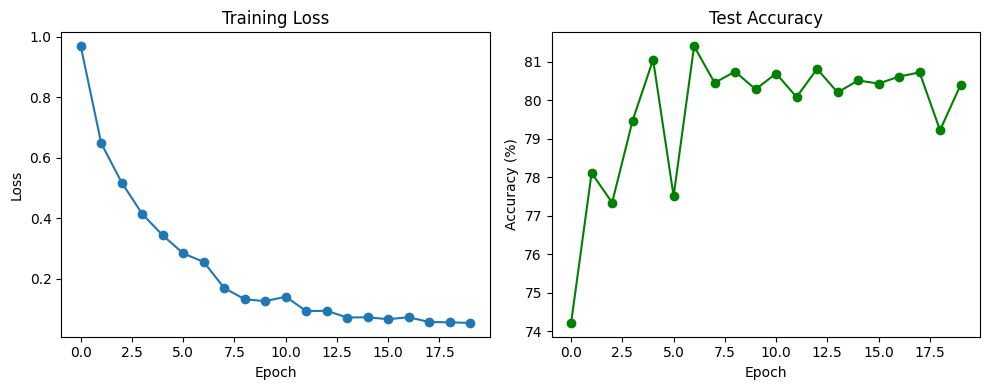

In [5]:
# Load ResNet18 and replace the classifier
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# Optional: Freeze backbone if you want feature extraction
# for param in model.parameters():
#     param.requires_grad = False

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train + evaluate
train_losses = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # Evaluate
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f}, Test Accuracy: {accuracy:.2f}%")

    # Save the model every 5 epochs
    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(), f"{save_path}/resnet18_epoch{epoch+1}.pth")

# Plotting
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label="Test Accuracy", marker='o', color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy")
plt.tight_layout()
plt.show()

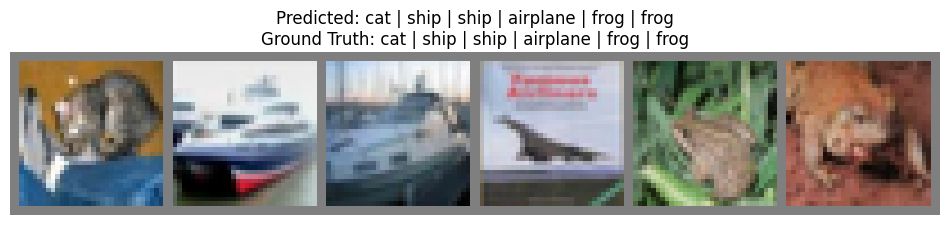

In [6]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# Load best model checkpoint
model.load_state_dict(torch.load(f"{save_path}/resnet18_epoch15.pth", map_location=device))
model.eval()

# Get test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Predict
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

# Display first 6 images
def imshow(img):
    img = img.cpu() * 0.5 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

plt.figure(figsize=(12, 6))
imshow(torchvision.utils.make_grid(images[:6]))
plt.title("Predicted: " + " | ".join([classes[p.item()] for p in predicted[:6]]) + 
          "\nGround Truth: " + " | ".join([classes[l.item()] for l in labels[:6]]))
plt.axis('off')
plt.show()